In [3]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Lambda, Flatten, Dense, Layer, Concatenate, GlobalAveragePooling2D, RandomFlip, RandomRotation
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFont, ImageDraw
import random
import os

In [4]:
def create_pairs(x, label_indices):
    """Positive and negative pair creation.
    Alternates between positive and negative pairs.
    """
    pairs = []
    labels = []

    # Get the unique labels in the dataset
    unique_labels = np.unique(list(label_indices.keys()))

    # Get the minimum number of images for any label, minus 1
    n = min([len(label_indices[l]) for l in unique_labels]) - 1

    for l in unique_labels:
        for i in range(n):
            # Create a positive pair (two images of the same label)
            z1, z2 = label_indices[l][i], label_indices[l][i + 1]
            pairs += [[x[z1], x[z2]]]

            # Create a negative pair (two images of different labels)
            # Ensure the new label is different from the current one
            other_labels = [ol for ol in unique_labels if ol != l]
            if other_labels: # Check if there are other labels
                ln = random.choice(other_labels)
                z1, z2 = label_indices[l][i], label_indices[ln][i]
                pairs += [[x[z1], x[z2]]]

                # Add labels: 1 for positive, 0 for negative
                labels += [1, 0]
            else:
                # If there are no other labels, just add the positive pair label
                labels += [1]


    return np.array(pairs), np.array(labels)

def create_pairs_on_set(images, labels):
    # Create a dictionary where keys are labels and values are arrays of indices
    unique_labels = np.unique(labels)
    label_indices = {l: np.where(labels == l)[0] for l in unique_labels}

    # Create the pairs using the main function
    pairs, y = create_pairs(images, label_indices)

    # Convert labels to float32
    y = y.astype('float32')

    return pairs, y

def show_image(image):
    plt.figure()
    plt.imshow(image)
    plt.colorbar()
    plt.grid(False)
    plt.show()

In [5]:
# Define the base directory where the zip file was extracted
base_directory = 'Sig-DS'
forg_dir = os.path.join(base_directory, 'signatures', 'full_forg')
org_dir = os.path.join(base_directory, 'signatures', 'full_org')

image_paths = []
labels = [] # This will store WRITER IDs (1-55), not genuine/forged

print(f"Loading genuine signatures from: {org_dir}")
for filename in os.listdir(org_dir):
    if filename.endswith('.png'):
      parts = filename.split('_')
      writer_id = int(parts[1])
      image_paths.append(os.path.join(org_dir, filename))
      labels.append(writer_id) # Append the actual writer ID

print(f"Found {len(image_paths)} genuine image paths.")
unique_writers = np.unique(labels)
print(f"Found {len(unique_writers)} unique writers.")

Loading genuine signatures from: Sig-DS\signatures\full_org
Found 1320 genuine image paths.
Found 55 unique writers.


In [6]:
# Load images and convert to grayscale
images = []
for img_path in image_paths:
    img = Image.open(img_path).convert('L') # Convert to grayscale
    images.append(img)

loaded_images = images
corresponding_labels = labels

print(f"Loaded {len(loaded_images)} images.")

Loaded 1320 images.


In [7]:
# Resize images
target_size = (128, 128)
resized_images = []
for img in loaded_images:
    img_resized = img.resize(target_size)
    resized_images.append(img_resized)

final_images = resized_images
final_labels = corresponding_labels

print(f"Resized {len(final_images)} images to {target_size}.")

Resized 1320 images to (128, 128).


In [8]:
# Normalize images and convert to numpy array
normalized_images = [np.array(img) / 255.0 for img in final_images]
# Add a 'channels' dimension at the end
normalized_images = np.array(normalized_images).reshape(-1, 128, 128, 1)
final_labels = np.array(final_labels)

print(f"Normalized and converted {len(normalized_images)} images to numpy array.")
print(f"Shape of normalized images: {normalized_images.shape}")
print(f"Shape of final labels: {final_labels.shape}")

Normalized and converted 1320 images to numpy array.
Shape of normalized images: (1320, 128, 128, 1)
Shape of final labels: (1320,)


In [9]:
# Organize the data for create_pairs_on_set
images_for_pairs = normalized_images
labels_for_pairs = final_labels

# Create pairs on the dataset
pairs, y = create_pairs_on_set(images_for_pairs, labels_for_pairs)

print(f"Created {len(pairs)} pairs.")
print(f"Shape of pairs: {pairs.shape}")
print(f"Shape of labels: {y.shape}")

Created 2530 pairs.
Shape of pairs: (2530, 2, 128, 128, 1)
Shape of labels: (2530,)


In [10]:
# Split the pairs and labels into training and testing sets
(tr_pairs, ts_pairs,
 tr_y, ts_y) = train_test_split(pairs, y, test_size=0.25, random_state=42)

print(f"Shape of training pairs: {tr_pairs.shape}")
print(f"Shape of testing pairs: {ts_pairs.shape}")
print(f"Shape of training labels: {tr_y.shape}")
print(f"Shape of testing labels: {ts_y.shape}")

Shape of training pairs: (1897, 2, 128, 128, 1)
Shape of testing pairs: (633, 2, 128, 128, 1)
Shape of training labels: (1897,)
Shape of testing labels: (633,)


Visualizing pair at index: 10


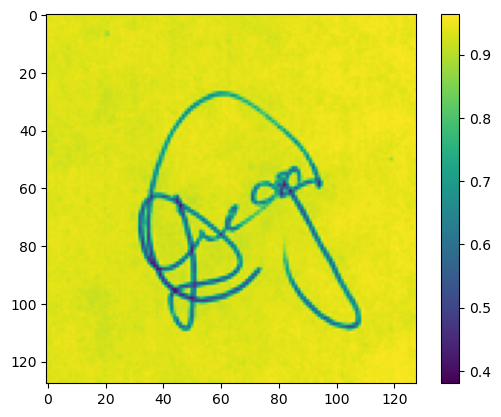

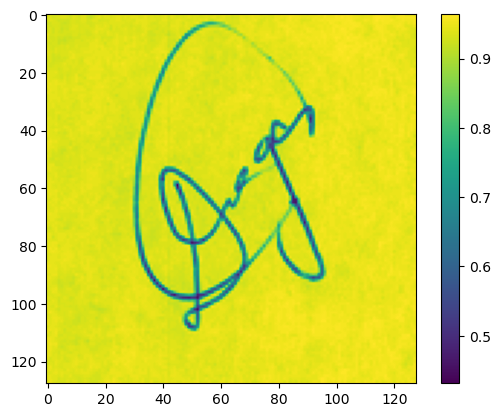

Label for this pair: 1.0


In [11]:
pair_index = 10

pairs_to_show = ts_pairs
labels_to_show = ts_y

# show images at this index
print(f"Visualizing pair at index: {pair_index}")
show_image(pairs_to_show[pair_index][0])
show_image(pairs_to_show[pair_index][1])

# print the label for this pair
print(f"Label for this pair: {labels_to_show[pair_index]}")

In [12]:
def initialize_base_network():

    #the input shape to match the 128x128 signature images

    # Input shape now includes the channel
    input = Input(shape=(128, 128, 1), name="base_input")

    # Convolutional layers
    x = Conv2D(32, (3, 3), activation='relu', name="conv1")(input)
    x = MaxPooling2D((2, 2), name="pool1")(x)
    x = Conv2D(64, (3, 3), activation='relu', name="conv2")(x)
    x = MaxPooling2D((2, 2), name="pool2")(x)

    # Flatten and then Dense layers
    x = Flatten(name="flatten_input")(x)
    x = Dense(128, activation='relu', name="first_base_dense")(x)
    x = Dropout(0.1, name="first_dropout")(x)
    x = Dense(128, activation='relu', name="second_base_dense")(x)

    return Model(inputs=input, outputs=x)


def euclidean_distance(vects):
    x, y = vects
    sum_square = K.sum(K.square(x - y), axis=1, keepdims=True)
    return K.sqrt(K.maximum(sum_square, K.epsilon()))


def eucl_dist_output_shape(shapes):
    shape1, shape2 = shapes
    return (shape1[0], 1)

In [13]:
pip install pydot

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [14]:
base_network = initialize_base_network()

plot_model(base_network, show_shapes=True, show_layer_names=True, to_file='base-model.png')

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [15]:
#create the left input and point to the base network
input_a = Input(shape=(128, 128, 1), name="left_input")
vect_output_a = base_network(input_a)
#create the right input and point to the base network
input_b = Input(shape=(128, 128, 1), name="right_input")
vect_output_b = base_network(input_b)

# measure the similarity of the two vector outputs
output = Lambda(euclidean_distance, name="output_layer", output_shape=eucl_dist_output_shape)([vect_output_a, vect_output_b])

# specify the inputs and output of the model
model = Model([input_a, input_b], output)

# plot model graph
plot_model(model, show_shapes=True, show_layer_names=True, to_file='outer-model.png')

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [16]:
def contrastive_loss_with_margin(margin):
    def contrastive_loss(y_true, y_pred):
        square_pred = K.square(y_pred)
        margin_square = K.square(K.maximum(margin - y_pred, 0))
        return K.mean(y_true * square_pred + (1 - y_true) * margin_square)
    return contrastive_loss

In [ ]:
rms = RMSprop()
model.compile(loss=contrastive_loss_with_margin(margin=1), optimizer=rms, metrics=['accuracy'])

history = model.fit(
    [tr_pairs[:, 0], tr_pairs[:, 1]],  # Input for 'left_input' and 'right_input'
    tr_y,
    validation_data=([ts_pairs[:, 0], ts_pairs[:, 1]], ts_y),
    epochs=15,  # Start with 15-20 and see
    batch_size=64
)

Epoch 1/15
 1/30 ━━━━━━━━━━━━━━━━━━━━ 8:05 17s/step - accuracy: 0.4844 - loss: 0.2763

In [ ]:
print(history.history.keys())

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def compute_accuracy(y_true, y_pred):
    pred = y_pred.ravel() > 0.5
    return np.mean(pred == y_true)

In [ ]:
loss = model.evaluate(x=[ts_pairs[:,0], ts_pairs[:,1]], y=ts_y)

y_pred_train = model.predict([tr_pairs[:,0], tr_pairs[:,1]])
train_accuracy = compute_accuracy(tr_y, y_pred_train)

y_pred_test = model.predict([ts_pairs[:,0], ts_pairs[:,1]])
test_accuracy = compute_accuracy(ts_y, y_pred_test)

print("Loss = {}, Train Accuracy = {} Test Accuracy = {}".format(loss, train_accuracy, test_accuracy))

In [ ]:
def plot_metrics(metric_name, title, ylim=5):
    plt.title(title)
    plt.ylim(0,ylim)
    plt.plot(history.history[metric_name],color='blue',label=metric_name)
    plt.plot(history.history['val_' + metric_name],color='green',label='val_' + metric_name)

plot_metrics(metric_name="loss", title="Loss", ylim=0.2)

In [ ]:
# Matplotlib config
def visualize_images():
    plt.rc('image', cmap='gray_r')
    plt.rc('grid', linewidth=0)
    plt.rc('xtick', top=False, bottom=False, labelsize='large')
    plt.rc('ytick', left=False, right=False, labelsize='large')
    plt.rc('axes', facecolor='F8F8F8', titlesize='large', edgecolor='white')
    plt.rc('text', color='A8151A')
    plt.rc('figure', facecolor='F0F0F0')# Matplotlib fonts


# utility to display a row of digits with their predictions
def display_images(left, right, predictions, labels, title, n):
    plt.figure(figsize=(17,3))
    plt.title(title)
    plt.yticks([])
    plt.xticks([])
    plt.grid(None)
    # Assuming images are 128x128. Adjust if your image size changes.
    img_height = left.shape[1]
    img_width = left.shape[2]

    left = np.reshape(left, [n, img_height, img_width])
    left = np.swapaxes(left, 0, 1)
    left = np.reshape(left, [img_height, img_width * n])
    plt.imshow(left, cmap='gray')

    plt.figure(figsize=(17,3))
    plt.yticks([])
    # Adjusting tick positions based on image width
    plt.xticks([img_width * x + img_width // 2 for x in range(n)], predictions)
    for i,t in enumerate(plt.gca().xaxis.get_ticklabels()):
        if predictions[i] > 0.5: t.set_color('red')
    plt.grid(None)
    right = np.reshape(right, [n, img_height, img_width])
    right = np.swapaxes(right, 0, 1)
    right = np.reshape(right, [img_height, img_width * n])
    plt.imshow(right, cmap='gray')

In [ ]:
y_pred_train = np.squeeze(y_pred_train)
indexes = np.random.choice(len(y_pred_train), size=10)
display_images(tr_pairs[:, 0][indexes,], tr_pairs[:, 1][indexes,], y_pred_train[indexes,], tr_y[indexes,], "Signatures and their dissimilarity", 10)